# Test loading a NASA NEX-GDDP-CMIP6 models output to compare with ERA5 0.25 $^{\circ}$ grid

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

### read in ERA5 file for comparison

In [92]:
filepath2 = "../../../Data/testing/era5_tas_1961.nc"
ds_era5 = xr.open_mfdataset(filepath2)

filepath_lsm = "../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc"
ds_lsm = xr.open_mfdataset(filepath_lsm)

ds_era5 = ds_era5.merge(ds_lsm)
ds_era5

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lon: 1440, lat: 721)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    tas      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    lsm      (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.7
    source:       ECMWF
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri Oct 02 14:42:17 2026: cdo -chname,t2m,tas era5_t2m_1961...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

Text(0.5, 1.0, 'Location: 49.25, -123.0')

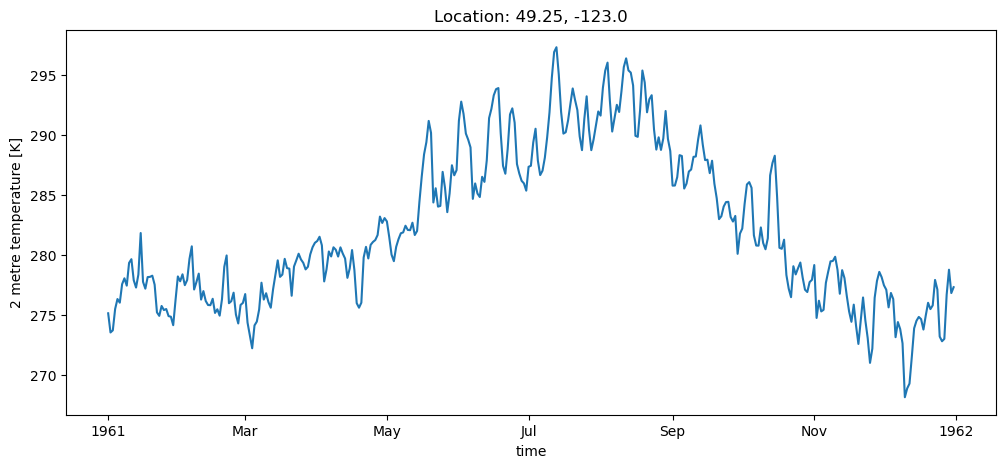

In [96]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116
plt.figure(figsize=(12,5))
ds_era5.tas.sel(lat=input_lat, lon=input_lon, method="nearest").plot()
plt.title("Location: "+str(ds_era5.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lat.values)+", "+str(ds_era5.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lon.values))

#### CESM2 data except it is after all the CDO steps to regrid to the full globe (as ERA5) and lon range

In [101]:
# after using cdo to make it the full global grid and change longitude range to -180 to 180 from 0-359.8
filepath = "../../../Data/testing/tas_CESM2_historical_1961_1440x721_-180_180.nc"
ds_cesm2 = xr.open_mfdataset(filepath)
ds_cesm2

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lat: 721, lon: 1440)
Coordinates:
  * time     (time) object 3kB 1961-01-01 00:00:00 ... 1961-12-31 00:00:00
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    tas      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes: (12/24)
    CDI:                   Climate Data Interface version 2.5.0 (https://mpim...
    Conventions:           CF-1.7
    source:                BCSD
    institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
    activity:              NEX-GDDP-CMIP6
    frequency:             day
    ...                    ...
    contact:               Dr. Bridget Thrasher: bridget@climateanalyticsgrou...
    creation_date:         Sat Nov 16 20:26:20 PST 2024
    disclaimer:            These data are considered provisional and subject ...
    tracking_id:           da98142a-5e4f-4c80-99d1-83ce9d7f6351
    history:               Fri Oct 02 15:19:00 2026: cdo -sellonlatbox,-180,1...
    CDO:                   Climate Data Operators version 2.5.0 (https://mpim...

#### update time variable - check how to do this with cdo to save time

In [103]:
# still need to update time variable - can I do this with CDO?
ds_cesm2['time'] = ds_cesm2.indexes['time'].to_datetimeindex()

### Vancouver time series from CESM2

In [107]:
ds_cesm2.lat.values

array([-90.  , -89.75, -89.5 , -89.25, -89.  , -88.75, -88.5 , -88.25,
       -88.  , -87.75, -87.5 , -87.25, -87.  , -86.75, -86.5 , -86.25,
       -86.  , -85.75, -85.5 , -85.25, -85.  , -84.75, -84.5 , -84.25,
       -84.  , -83.75, -83.5 , -83.25, -83.  , -82.75, -82.5 , -82.25,
       -82.  , -81.75, -81.5 , -81.25, -81.  , -80.75, -80.5 , -80.25,
       -80.  , -79.75, -79.5 , -79.25, -79.  , -78.75, -78.5 , -78.25,
       -78.  , -77.75, -77.5 , -77.25, -77.  , -76.75, -76.5 , -76.25,
       -76.  , -75.75, -75.5 , -75.25, -75.  , -74.75, -74.5 , -74.25,
       -74.  , -73.75, -73.5 , -73.25, -73.  , -72.75, -72.5 , -72.25,
       -72.  , -71.75, -71.5 , -71.25, -71.  , -70.75, -70.5 , -70.25,
       -70.  , -69.75, -69.5 , -69.25, -69.  , -68.75, -68.5 , -68.25,
       -68.  , -67.75, -67.5 , -67.25, -67.  , -66.75, -66.5 , -66.25,
       -66.  , -65.75, -65.5 , -65.25, -65.  , -64.75, -64.5 , -64.25,
       -64.  , -63.75, -63.5 , -63.25, -63.  , -62.75, -62.5 , -62.25,
      

Text(0.5, 1.0, 'Location: 49.25, -123.0')

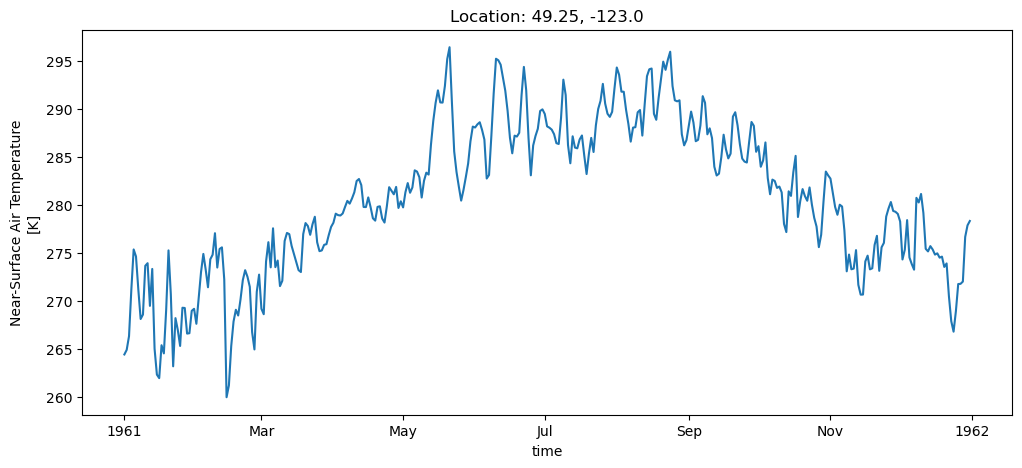

In [109]:
# Vancouver
plt.figure(figsize=(12,5))
ds_cesm2.tas.sel(lat=input_lat, lon=input_lon, method="nearest").plot()
plt.title("Location: "+str(ds_cesm2.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lat.values)+", "+str(ds_cesm2.tas.sel(lat=input_lat, lon=input_lon, method="nearest").lon.values))

#### Difference in time series CESM2 and ERA5

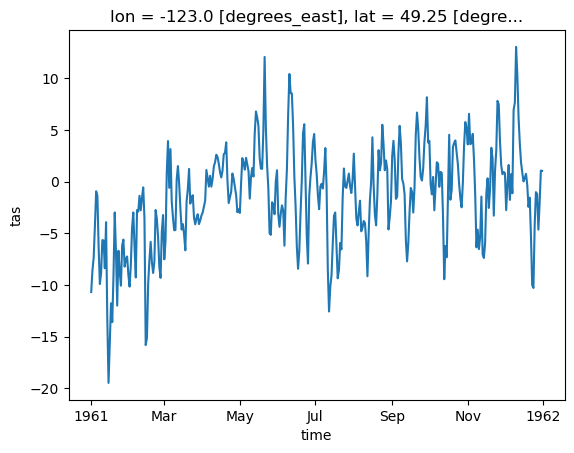

In [110]:
(ds_cesm2.tas.sel(lat=input_lat, lon=input_lon, method="nearest") - ds_era5.tas.sel(lat=input_lat, lon=input_lon, method="nearest")).plot()

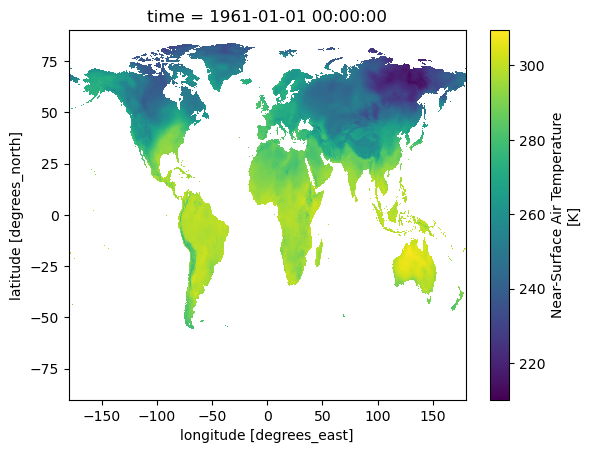

In [69]:
ds_cesm2.tas.sel(time="1961-01-01").plot()

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lon: 1440, lat: 721)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1961-01-01 1961-01-02 ... 1961-12-31
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    tas      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    lsm      (lat, lon) float64 8MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.7
    source:       ECMWF
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri Oct 02 14:42:17 2026: cdo -chname,t2m,tas era5_t2m_1961...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

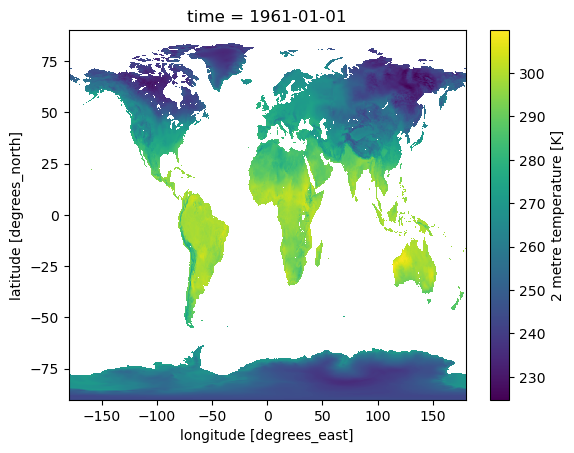

In [75]:
ds_era5_land = ds_era5.where(ds_era5.lsm > 0.5)
    
ds_era5_land.tas.sel(time="1961-01-01").plot()

In [76]:
ds_cesm2, ds_era5_land


(<xarray.Dataset> Size: 2GB
 Dimensions:  (time: 365, lat: 721, lon: 1440)
 Coordinates:
   * time     (time) object 3kB 1961-01-01 00:00:00 ... 1961-12-31 00:00:00
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
 Data variables:
     tas      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
 Attributes: (12/24)
     CDI:                   Climate Data Interface version 2.5.0 (https://mpim...
     Conventions:           CF-1.7
     source:                BCSD
     institution:           NASA Earth Exchange, NASA Ames Research Center, Mo...
     activity:              NEX-GDDP-CMIP6
     frequency:             day
     ...                    ...
     contact:               Dr. Bridget Thrasher: bridget@climateanalyticsgrou...
     creation_date:         Sat Nov 16 20:26:20 PST 2024
     disclaimer:            These data are considered provisional an

### Plot them side by side

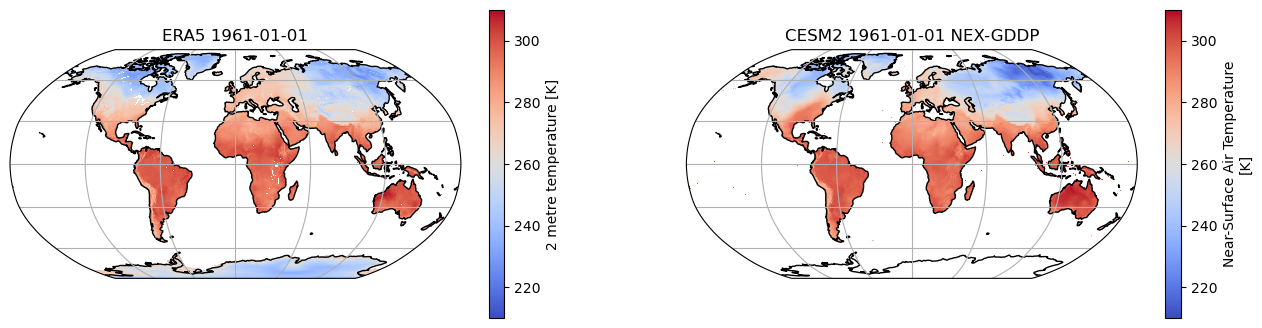

CPU times: user 4.62 s, sys: 162 ms, total: 4.78 s
Wall time: 4.8 s


In [79]:
%%time

fig = plt.figure(figsize=(16,8))
    
ax1 = fig.add_subplot(1,2,1, projection=ccrs.Robinson(central_longitude=0))
# add coastlines and grid
ax1.coastlines()
ax1.gridlines()

ds_era5_land.tas.sel(time="1961-01-01").plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=210,
    vmax=310, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)
ax1.set_title("ERA5 1961-01-01")

ax2 = fig.add_subplot(1,2,2, projection=ccrs.Robinson(central_longitude=0))
# assign axis and def projection to use
# add coastlines and grid
ax2.coastlines()
ax2.gridlines()

ds_cesm2.tas.sel(time="1961-01-01").plot(
    ax=ax2,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=210,
    vmax=310, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5}
)
ax2.set_title("CESM2 1961-01-01 NEX-GDDP")
#plt.tight_layout()
plt.show()


#### Plot difference

Text(0.5, 1.0, 'CESM2 - ERA5 Anomaly 1961-01-01')

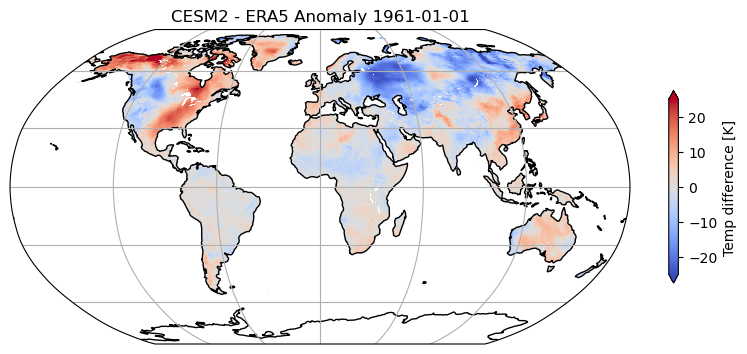

In [87]:
era5_tas = ds_era5_land.tas.sel(time="1961-01-01")
cesm2_tas = ds_cesm2.tas.sel(time="1961-01-01")
da_diff = cesm2_tas - era5_tas
fig = plt.figure(figsize=(10,5))
    
ax1 = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=0))
# add coastlines and grid
ax1.coastlines()
ax1.gridlines()

da_diff.sel(time="1961-01-01").plot(
    ax=ax1,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-25,
    vmax=25, # define range to include an entire year
    cmap="coolwarm",#"YlOrRd"#cmap="coolwarm"
    cbar_kwargs={'shrink': 0.5, 'label': 'Temp difference [K]'}
)
ax1.set_title("CESM2 - ERA5 Anomaly 1961-01-01")